# **Merging the information from both tables related to Police data**

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
query = """
SELECT *
FROM `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.src_BD_IncidentData`
"""

query2 = """
SELECT *
FROM `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.src_cb_incident_cleaned_2020-04_to_2022-03`
"""

In [3]:
client = bigquery.Client()

In [4]:
dataset_1 = list(client.query(query).result())
dataset_2 = list(client.query(query2).result())

df_1 = pd.DataFrame([dict(row.items()) for row in dataset_1])
df_2 = pd.DataFrame([dict(row.items()) for row in dataset_2])

In [5]:
df_2 = df_2[df_2.qualifiers.str.contains('MENTAL HEALTH')]

In [6]:
complete_df = pd.concat([df_1,df_2], ignore_index=True, sort=False)

In [7]:
complete_df['incident_duration'] = (complete_df['incident_end_date']-complete_df['incident_start_date']).dt.days

In [8]:
df = complete_df.drop_duplicates()

print(f"The number of rows dropped: {len(complete_df)-len(df)}")

The number of rows dropped: 0


In [9]:
# Mark duplicates (both directions)
df['is_duplicate'] = df.duplicated() | df.duplicated(keep='last')

duplicates_only = df[df['is_duplicate']]
duplicates_only

,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,...,final_grade,incident_end_date,cb_date_added,incident_type,lsoa_name,incident_start_date,postcode_district,incident_id,incident_duration,is_duplicate


In [10]:
missing_count = df[df['lsoa'].isna() & (df['attended'] == True)].shape[0]

print(f"The number of missing values in LSOA and attended: {missing_count}")

The number of missing values in LSOA and attended: 75


In [11]:
df_lsoa = pd.read_csv('Lower_Layer_Super_Output_Areas_(December_2011)_Names_and_Codes_in_England_and_Wales.csv')
df_lsoa_bradford = df_lsoa[df_lsoa.LSOA11NM.str.contains("Bradford")]

df_joined = df[df.lsoa.isin(df_lsoa_bradford.LSOA11CD)]

In [12]:
print(f"The number of rows dropped: {len(df)-len(df_joined)}")

The number of rows dropped: 218


In [13]:
# Crime Incidents identified by Dan and Amanda
OurCrimeIncidentsTypesList = ["VIOLENCE AGAINST PERSON", "PUBLIC ORDER", "PUBLIC ORDER - SERIOUS DISORDER",  "PUBLIC ORDER - BREACH OF ASBO",
                      "HARASSMENT", "WEAPON - USED OR INVOLVED", "PUBLIC ORDER RELATED", "FIREARMS", 
                      "THREATS TO KILL", "SEXUAL OFFENCE", "FORCED MARRIAGE", "HATE INCIDENT- CRIME", "BURGLARY - RESIDENTIAL", 
                          "BURGLARY - BUSINESS & COMMUNITY", "MODERN SLAVERY", "ROBBERY", "ROBBERY - BANKS, CIT ETC", "FOUND STOLEN VEHICLE", 
                          "THEFT OF A VEHICLE", "THEFT FROM A VEHICLE", "THEFT - OTHER / HANDLING", "THEFT - SHOPLIFTING", 
                           "THEFT - MAKE OFF WITHOUT PAYMENT", "THEFT - FROM PERSON", "FRAUD/FORGERY", "ACTION FRAUD", "BANKING PROTOCOL (FRAUD)", 
                            "DRUGS", "ABDUCTION", "KIDNAP", "BLACKMAIL / EXTORTION", "HOMICIDE", 
                           "NO CRIME RECORDED (EG VICTIM NOT LOCATED)", "OTHER NOTIFIABLE CRIME", "CRIMINAL DAMAGE", 
                           "ASSAULT - SERIOUS INJURY", "CRIMINAL DAMAGE (HATE)", "HATE CRIME RELATED", "VIOLENCE AGAINST PERSON (HATE)", 
                           "BANKING PROTOCOL (FRAUD)", "DOMESTIC (NON CRIME)", "FIREARMS (NON CRIME)", "FORCED MARRIAGE (NON CRIME)", 
                              "HATE INCIDENT- NON CRIME", "HONOUR BASED VIOLENCE (NON CRIME)", "SUSP CIRCS - INV VEHICLE", "SUSPICIOUS CIRCUMSTANCES"]

IncidentTypestodrop = ["ABANDONED / NO INFORMATION","POLICE GENERATED ACTIVITY","MESSAGE","ANPR GENERATED","CCC USE ONLY - INFO LOG","OPENED IN ERROR","TRAINING LOG ONLY"]

Road_traffic = ["RTC - DAMAGE ONLY - DET EXCH NFA","RTC - SLIGHT INJURY - DET EXCH NFA","RTC - DAMAGE ONLY - OFFENCE ENQS",
                "RTC - SERIOUS INJURY","RTC - SLIGHT INJURY - OFFENCE ENQS","RTC - DAMAGE ONLY - POLICE","RTC - SLIGHT INJURY - POLICE",
                "RTC - FATAL","RTC - SLIGHT INJURY - TOR ISSUED","RTC - SERIOUS INJURY - POLICE","RTC - FATAL - POLICE","RTC - DAMAGE ONLY - TOR ISSUED"]

Missing_person = ["MISPER - MEDIUM RISK","MISPER - HIGH RISK","MISPER - NO APPARENT RISK","MISPER - LOW RISK","RETURNED MISPER FOLLOW UP LOG",
                  "MISPER - NO NICHE"]

Sexual_offence = ["OTHER SEXUAL OFFENCE","SEXUAL - RAPE","SERIOUS SEXUAL OFFENCE"]

In [14]:
df_joined = df_joined[~df_joined.incident_type.isin(IncidentTypestodrop)] #2001 rows dropped
df_joined['incident_type'] = np.where(df_joined.incident_type.isin(Road_traffic),"ROAD TRAFFIC COLLISON",df_joined['incident_type'])
df_joined['incident_type'] = np.where(df_joined.incident_type.isin(Missing_person),"MISSING PERSON",df_joined['incident_type'])
df_joined['incident_type'] = np.where(df_joined.incident_type.isin(Sexual_offence),"SEXUAL OFFENCE",df_joined['incident_type'])
df_joined['incident_type'] = np.where(df_joined.incident_type=="RSSS EXAMINATION","ROUGH SLEEPING SUPPORT SERVICE",df_joined['incident_type'])
df_joined = df_joined[df_joined.incident_type.notna()]

In [15]:
asb_hate = ["NUISANCE (HATE)","PERSONAL (HATE)","ENVIRONMENT (HATE)"]
asb = ["NUISANCE","PERSONAL","ENVIRONMENT"]

df_joined['incident_type'] = np.where(df_joined.incident_type.isin(asb_hate),"ASB (HATE)",df_joined['incident_type'])
df_joined['incident_type'] = np.where(df_joined.incident_type.isin(asb),"ASB",df_joined['incident_type'])

In [16]:
sns.set(rc={'figure.figsize':(11, 4)})
font_properties = {'family': 'sans-serif','weight': 'bold','size': 12}
tickfont_properties = {'family': 'sans-serif','size': 9}

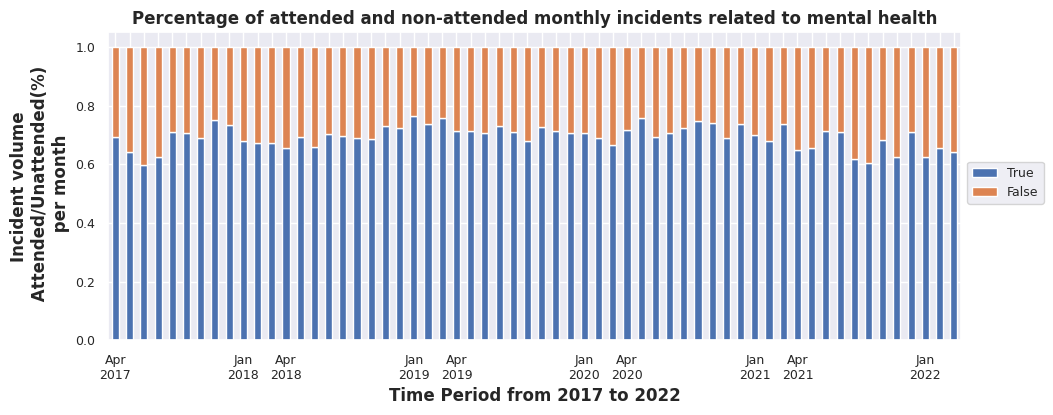

In [17]:
# Calculate volume of attended and unattended incidents
df_attended = df_joined[~(df_joined.final_grade.isin(["EMERGENCY", "PRIORITY"]) & (df_joined.incident_duration>5))]
df_attended['Date_agg_month'] = df_attended['incident_start_date'].dt.to_period('M')
Vol_attended = df_attended.groupby(['Date_agg_month','attended']).size().unstack(fill_value=0)
Vol_attended = Vol_attended.div(Vol_attended.sum(axis=1),axis=0)
Vol_attended = Vol_attended.sort_index(axis=1,level='attended',ascending=False)

fig, ax = plt.subplots()
Vol_attended.plot(ax=ax,kind='bar',stacked=True)

xticks = Vol_attended.index
xtick_labels = [p.strftime('%b\n%Y') if p.month in [1,4] else '' for p in xticks]

ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xtick_labels,rotation=0)
ax.legend(prop=tickfont_properties,bbox_to_anchor=(1, 0.6))
plt.xlabel('Time Period from 2017 to 2022',**font_properties)

plt.xticks(**tickfont_properties)
plt.yticks(**tickfont_properties)
plt.ylabel('Incident volume\n Attended/Unattended(%)\n per month',**font_properties)
plt.title('Percentage of attended and non-attended monthly incidents related to mental health',**font_properties)
plt.show()

In [18]:
incident_grade = ["EMERGENCY", "PRIORITY", "STANDARD"]

# df_grade = df_joined[(df_joined.final_grade.isin(incident_grade) & (df_joined.attended==True))]
df_grade = df_joined[df_joined.final_grade.isin(incident_grade)]

print(f"The number of dropped rows: {len(df_joined)-len(df_grade)}")

The number of dropped rows: 607


In [19]:
print(f"The number of observations after cleaning:{len(df_grade)}")

The number of observations after cleaning:24487


In [20]:
len(np.where(df_grade.final_grade.isin(["EMERGENCY", "PRIORITY"]))[0])

14324

In [21]:
df_grade = df_grade[~(df_grade.final_grade.isin(["EMERGENCY", "PRIORITY"]) & (df_grade.incident_duration>5))]
print(f"The number of observations after cleaning:{len(df_grade)}")

The number of observations after cleaning:24442


In [22]:
def wrangle_date_col(dataframe, date_col):
    dataframe[date_col] = pd.to_datetime(dataframe[date_col])
    nw_col_name = "_".join(date_col.split('_')[:2])
    dataframe[nw_col_name+"_"+str("year")] = dataframe[date_col].dt.year
    dataframe[nw_col_name+"_"+str("month")] = dataframe[date_col].dt.month_name()
    dataframe[nw_col_name+"_"+str("day_num")] = dataframe[date_col].dt.day
    dataframe[nw_col_name+"_"+str("day")] = dataframe[date_col].dt.day_name()
    dataframe[nw_col_name+"_"+str("hour")] = dataframe[date_col].dt.hour
    
    return dataframe

In [23]:
df_final = wrangle_date_col(df_grade,'incident_start_date')
df_final = wrangle_date_col(df_grade,'incident_end_date')

In [24]:
df_final['Date_agg'] = df_final['incident_start_date'].dt.to_period('M').dt.to_timestamp()

In [25]:
# Define conditions and corresponding values
conditions = [
    (df_final.Date_agg.dt.year  == 2017) & (df_final.Date_agg.dt.month.between(4, 12)),
    (df_final.Date_agg.dt.year  == 2018) & (df_final.Date_agg.dt.month.between(1, 3)),
    (df_final.Date_agg.dt.year  == 2018) & (df_final.Date_agg.dt.month.between(4, 12)),
    (df_final.Date_agg.dt.year  == 2019) & (df_final.Date_agg.dt.month.between(1, 3)),
    (df_final.Date_agg.dt.year  == 2019) & (df_final.Date_agg.dt.month.between(4, 12)),
    (df_final.Date_agg.dt.year  == 2020) & (df_final.Date_agg.dt.month.between(1, 3)),
    (df_final.Date_agg.dt.year  == 2020) & (df_final.Date_agg.dt.month.between(4, 12)),
    (df_final.Date_agg.dt.year  == 2021) & (df_final.Date_agg.dt.month.between(1, 3)),
    (df_final.Date_agg.dt.year == 2021) & (df_final.Date_agg.dt.month.between(4, 12)),
    (df_final.Date_agg.dt.year == 2022) & (df_final.Date_agg.dt.month.between(1, 3))]

values = ['17-18', '17-18', '18-19', '18-19', '19-20', '19-20', '20-21', '20-21', '21-22', '21-22']

In [26]:
df_final['YearTrunk'] = np.select(conditions, values, default='Other')

In [27]:
df_final['CrimeTag'] =  np.where(df_final.incident_type.isin(OurCrimeIncidentsTypesList),"Crime","Non-Crime")

In [28]:
# Group by 'CrimeTag' and 'YearTrunk' and count the number of rows per group
call_volume = df_final.groupby(['CrimeTag', 'YearTrunk']).size().reset_index(name='CallVolume')

# Pivot the table
call_volume_wide = call_volume.pivot(index='CrimeTag', columns='YearTrunk', values='CallVolume').fillna(0)

# Compute 'Total' column summing across specific year columns
call_volume_wide['Total'] = call_volume_wide[['17-18', '18-19', '19-20', '20-21', '21-22']].sum(axis=1)
summary_row = call_volume_wide[['17-18', '18-19', '19-20', '20-21', '21-22','Total']].sum(axis=0)
call_volume_wide = pd.concat([call_volume_wide, pd.DataFrame(summary_row).T], ignore_index=True)

call_volume_wide.index = ["Crime", "Non-Crime", "Row Total"]

In [29]:
# Values considering both attended and unattended
call_volume_wide

YearTrunk,17-18,18-19,19-20,20-21,21-22,Total
Crime,683,980,997,1072,883,4615
Non-Crime,3134,4037,4313,4392,3951,19827
Row Total,3817,5017,5310,5464,4834,24442


In [30]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24442 entries, 327 to 27302
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   lsoa_name1              14144 non-null  object             
 1   Index                   0 non-null      object             
 2   lsoa1                   14144 non-null  object             
 3   lsoa                    24442 non-null  object             
 4   incident_ref            14144 non-null  object             
 5   reswodep                24442 non-null  bool               
 6   initial_grade           13456 non-null  object             
 7   attended                24442 non-null  bool               
 8   incident_sub_type       12810 non-null  object             
 9   disposition_1_code      14144 non-null  float64            
 10  qualifiers              24428 non-null  object             
 11  final_grade             24442 non-null  obje

In [31]:
df_final[~(df_final.qualifiers.str.contains('MENTAL HEALTH',na=False))]

,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,...,incident_start_day,incident_start_hour,incident_end_year,incident_end_month,incident_end_day_num,incident_end_day,incident_end_hour,Date_agg,YearTrunk,CrimeTag
1446,Bradford 020B,None,E01010782,E01010782,WYP-20170611-0138,False,None,True,None,665.0,...,Sunday,1,2017,June,11,Sunday,2,2017-06-01,17-18,Non-Crime
2133,Bradford 026C,None,E01010655,E01010655,WYP-20190226-1905,False,None,True,NICHE CREATE OCCURRENCE,400.0,...,Tuesday,21,2019,February,27,Wednesday,0,2019-02-01,18-19,Crime
3408,Bradford 039G,None,E01033690,E01033690,WYP-20190115-1530,False,None,True,NICHE CREATE OCCURRENCE,400.0,...,Tuesday,18,2019,January,15,Tuesday,22,2019-01-01,18-19,Crime
6184,Bradford 012C,None,E01010718,E01010718,WYP-20191230-0395,False,None,True,None,665.0,...,Monday,10,2019,December,30,Monday,19,2019-12-01,19-20,Non-Crime
7511,Bradford 038A,None,E01010618,E01010618,WYP-20190206-1599,False,None,True,NICHE CREATE OCCURRENCE,480.0,...,Wednesday,18,2019,February,6,Wednesday,22,2019-02-01,18-19,Crime
7699,Bradford 039G,None,E01033690,E01033690,WYP-20190322-2170,False,None,True,None,660.0,...,Friday,23,2019,March,23,Saturday,0,2019-03-01,18-19,Non-Crime
7858,Bradford 040B,None,E01010629,E01010629,WYP-20190215-1775,False,None,True,NO OCCURRENCE REQUIRED,498.0,...,Friday,20,2019,February,15,Friday,23,2019-02-01,18-19,Crime
10711,Bradford 025C,None,E01010792,E01010792,WYP-20181215-0406,True,PRIORITY,False,None,620.0,...,Saturday,6,2018,December,21,Friday,22,2018-12-01,18-19,Crime
12739,Bradford 037D,None,E01010813,E01010813,WYP-20170823-0048,False,PRIORITY,True,None,665.0,...,Wednesday,0,2017,August,23,Wednesday,1,2017-08-01,17-18,Non-Crime
13378,Bradford 039J,None,E01033693,E01033693,WYP-20180228-1217,False,None,True,NICHE CREATE OCCURRENCE,499.0,...,Wednesday,15,2018,March,1,Thursday,17,2018-02-01,17-18,Crime


In [32]:
df_final = df_final[(df_final.qualifiers.str.contains('MENTAL HEALTH',na=False))]
len(df_final)

24428

In [33]:
df_final.to_csv('BD_Policedata_2017_22_all.csv')